In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    r"C:\Users\salon\OneDrive\Desktop\Data_Science\SQL Projects\E commerce customer churn\ecommerce_churn.csv"
)

In [5]:
# Create a working copy

df = df.copy()

print("Dataset shape:", df.shape)

Dataset shape: (5630, 20)


## Baisc dataset exploration

In [4]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [5]:
df.sample(5, random_state=42)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4331,54332,1,1.0,Computer,3,7.0,COD,Female,4.0,6,Mobile Phone,5,Single,2,0,22.0,2.0,2.0,1.0,148
1988,51989,0,15.0,Mobile Phone,1,9.0,Debit Card,Female,3.0,1,Laptop & Accessory,1,Married,3,1,13.0,1.0,1.0,3.0,152
3443,53444,0,13.0,Computer,1,29.0,Credit Card,Female,3.0,4,Fashion,5,Single,3,1,14.0,2.0,NaN,9.0,234
4559,54560,0,5.0,Phone,1,7.0,Debit Card,Male,4.0,5,Mobile Phone,5,Married,3,0,13.0,4.0,4.0,3.0,147
4898,54899,0,13.0,Mobile Phone,1,7.0,Debit Card,Female,4.0,5,Grocery,1,Married,3,0,17.0,10.0,NaN,9.0,252


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [7]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing_Count",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
DaySinceLastOrder,307,5.452931
OrderAmountHikeFromlastYear,265,4.706927
Tenure,264,4.689165
OrderCount,258,4.582593
CouponUsed,256,4.547069
HourSpendOnApp,255,4.529307
WarehouseToHome,251,4.458259
CustomerID,0,0.000000
MaritalStatus,0,0.000000
Complain,0,0.000000


Several behavioural and order-related features contain missing values, with DaySinceLastOrder having the highest number of missing observations. Instead of removing these records immediately, I will first investigate whether the missing values are associated with customer churn.

In [8]:
# Count empty strings in each column

empty_strings = (df == "").sum()

empty_strings[empty_strings > 0]

Series([], dtype: int64)

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Target variable

In [10]:
print(df["Churn"].value_counts())

Churn
0    4682
1     948
Name: count, dtype: int64


In [11]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


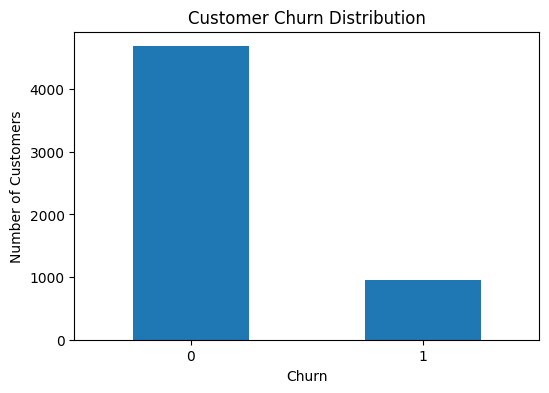

In [12]:
df["Churn"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [13]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [14]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.0,0.00,1.0
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.0,16.00,61.0
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.0,3.00,3.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.0,20.00,127.0
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.0,3.00,5.0
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.0,4.00,6.0
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.0,4.00,5.0
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.0,6.00,22.0
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.0,1.00,1.0


In [15]:
for col in categorical_cols:
    print("-------------------------------")
    print(df[col].value_counts(dropna=False))

-------------------------------
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
-------------------------------
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
-------------------------------
Gender
Male      3384
Female    2246
Name: count, dtype: int64
-------------------------------
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
-------------------------------
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


In [16]:
df_raw = df.copy()

print("Raw dataset shape:", df_raw.shape)

Raw dataset shape: (5630, 20)


In [17]:
payment_mapping = {
    "CC": "Credit Card",
    "COD": "Cash on Delivery",
    "Cash on Delivery": "Cash on Delivery"
}

df["PreferredPaymentMode"] = (
    df["PreferredPaymentMode"]
    .replace(payment_mapping)
)

print(df["PreferredPaymentMode"].value_counts())

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64


## Distribution of Numeric features

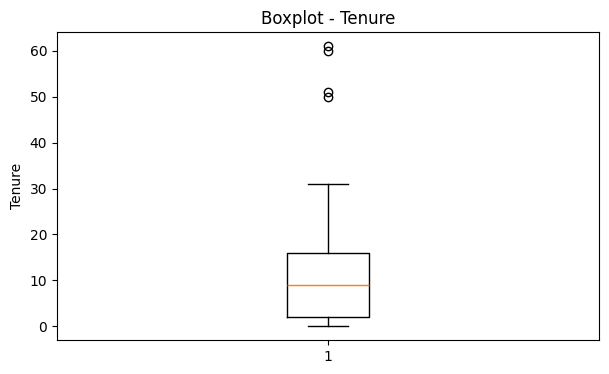

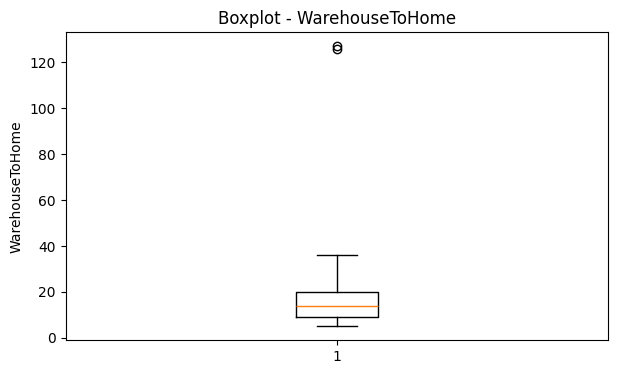

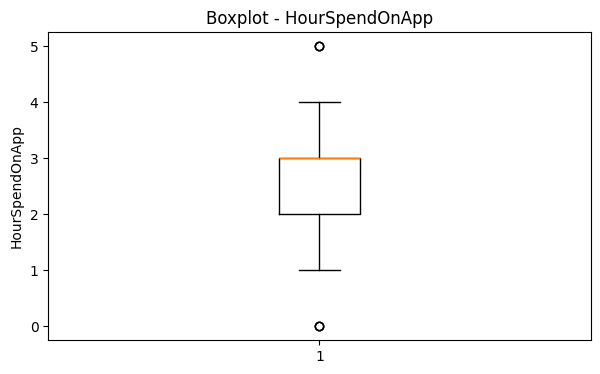

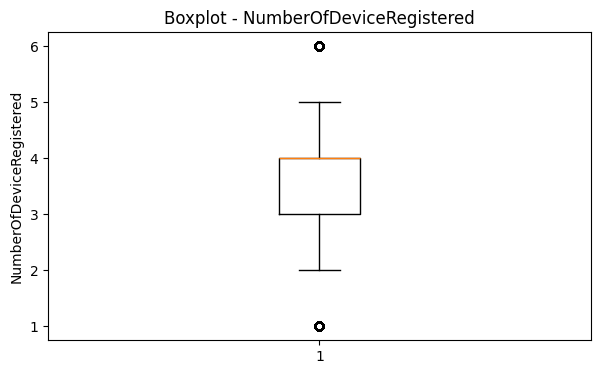

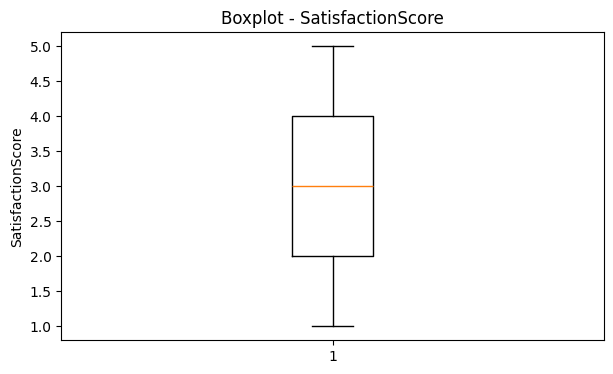

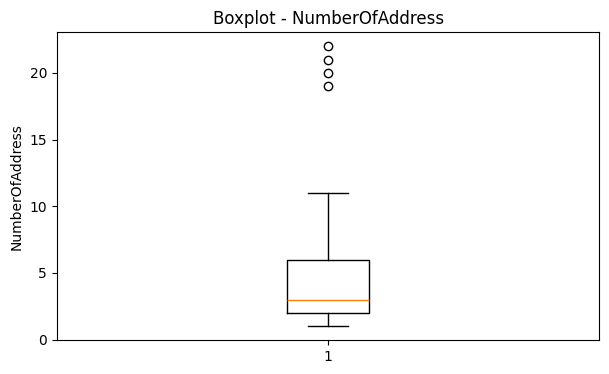

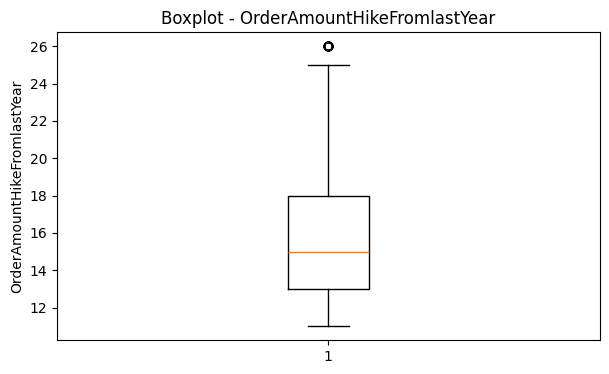

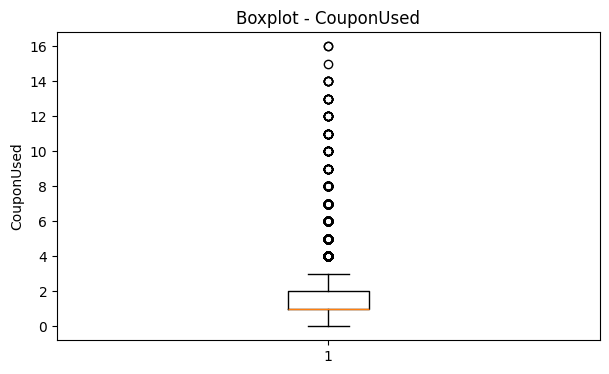

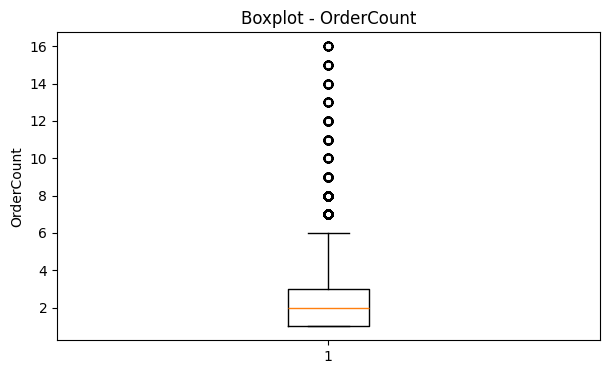

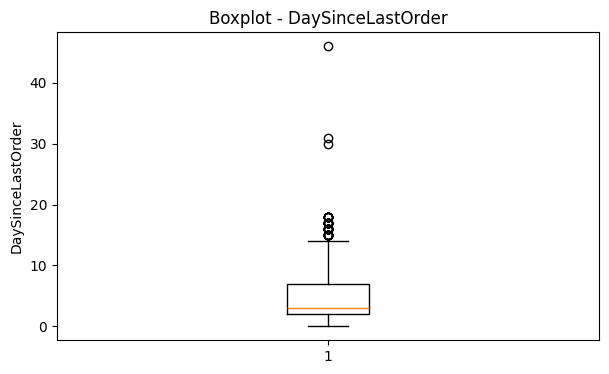

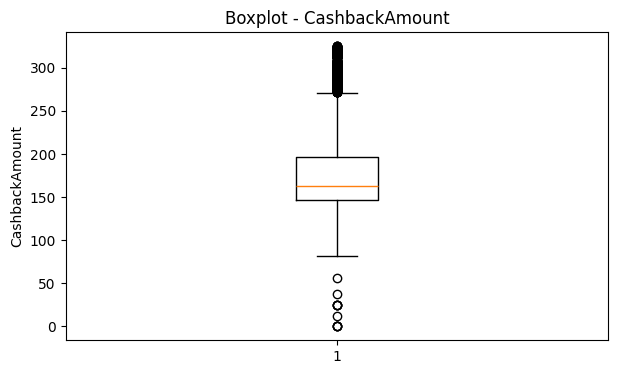

In [18]:
import matplotlib.pyplot as plt

numeric_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.show()

In [19]:
missing_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder"
]

for col in missing_columns:

    df["is_missing"] = df[col].isna()

    result = df.groupby("is_missing")["Churn"].agg(
        ["count", "mean"]
    )

    print(col)
    print('-------------------------')
    print(result, '\n')

Tenure
-------------------------
            count      mean
is_missing                 
False        5366  0.161573
True          264  0.306818 

WarehouseToHome
-------------------------
            count      mean
is_missing                 
False        5379  0.160625
True          251  0.334661 

HourSpendOnApp
-------------------------
            count      mean
is_missing                 
False        5375  0.165581
True          255  0.227451 

OrderAmountHikeFromlastYear
-------------------------
            count      mean
is_missing                 
False        5365  0.174091
True          265  0.052830 

CouponUsed
-------------------------
            count      mean
is_missing                 
False        5374  0.174916
True          256  0.031250 

OrderCount
-------------------------
            count      mean
is_missing                 
False        5372  0.173120
True          258  0.069767 

DaySinceLastOrder
-------------------------
            count      mean


In [20]:
df.drop(columns="is_missing", inplace=True)

In [21]:
from scipy.stats import chi2_contingency

def test_missingness_vs_churn(df, columns):

    results = []

    for col in columns:

        missing_flag = df[col].isna()

        contingency_table = pd.crosstab(
            missing_flag,
            df["Churn"]
        )

        chi2, p_value, dof, expected = chi2_contingency(
            contingency_table
        )

        results.append({
            "Feature": col,
            "Chi2": chi2,
            "p_value": p_value,
            "Significant": p_value < 0.05
        })

    return pd.DataFrame(results).sort_values("p_value")


missing_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder"
]

missingness_tests = test_missingness_vs_churn(
    df,
    missing_columns
)

missingness_tests

,Feature,Chi2,p_value,Significant
1,WarehouseToHome,50.635715,1.112029e-12,True
0,Tenure,36.877562,1.257852e-09,True
4,CouponUsed,34.999034,3.298690e-09,True
3,OrderAmountHikeFromlastYear,25.658302,4.075383e-07,True
5,OrderCount,18.047895,2.154167e-05,True
2,HourSpendOnApp,6.220407,1.262861e-02,True
6,DaySinceLastOrder,0.080266,7.769376e-01,False


The analysis shows that missingness is not equally distributed between churned and retained customers. For several variables, customers with missing values have noticeably different churn rates. **This suggests that missingness itself may contain useful information and should be considered carefully during modelling.**

In [22]:
df[df["WarehouseToHome"] > 50][
    ["WarehouseToHome", "Churn"]
].sort_values("WarehouseToHome", ascending=False)

,WarehouseToHome,Churn
4124,127.0,0
1309,126.0,0


In [23]:
print(
    "Values > 50:",
    (df["WarehouseToHome"] > 50).sum()
)

Values > 50: 2


In [24]:
df.loc[
    df["WarehouseToHome"] > 50,
    :
]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1309,51310,0,25.0,Computer,3,126.0,Debit Card,Male,2.0,3,Mobile,1,Married,3,0,15.0,1.0,1.0,0.0,135
4124,54125,0,26.0,Computer,3,127.0,Debit Card,Male,3.0,4,Mobile Phone,1,Married,4,0,16.0,2.0,2.0,1.0,160


In [25]:
# Correct identified data-entry errors

df.loc[df["WarehouseToHome"] == 126, "WarehouseToHome"] = 26
df.loc[df["WarehouseToHome"] == 127, "WarehouseToHome"] = 27

print(df["WarehouseToHome"].max())

36.0


Two unusually high values (126 and 127) were identified in WarehouseToHome, while most observations fall within a much smaller range. After checking the corresponding records, these values appeared to be data-entry errors rather than genuine distances. They were corrected to 26 and 27 respectively rather than removing the customers.

# EDA

In [26]:
binary_features = [
    "Complain"
]

for col in binary_features:

    result = (
        df.groupby(col)["Churn"]
        .agg(["count", "sum", "mean"])
    )

    result["churn_rate_%"] = result["mean"] * 100

    print(f"\n{col}")
    print(result.round(2))


Complain
          count  sum  mean  churn_rate_%
Complain                                
0          4026  440  0.11         10.93
1          1604  508  0.32         31.67


## Numerical Features vs Churn

In [27]:
numerical_analysis = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

summary = df.groupby("Churn")[numerical_analysis].agg(
    ["mean", "median"]
)

summary

Tenure        WarehouseToHome        HourSpendOnApp         \
            mean median            mean median           mean median   
Churn                                                                  
0      11.502334   10.0       15.309635   13.0       2.925530    3.0   
1       3.379469    1.0       17.134259   15.0       2.961798    3.0   

      NumberOfDeviceRegistered        SatisfactionScore         ...  \
                          mean median              mean median  ...   
Churn                                                           ...   
0                     3.639257    4.0          3.001282    3.0  ...   
1                     3.934599    4.0          3.390295    3.0  ...   

      OrderAmountHikeFromlastYear        CouponUsed        OrderCount         \
                             mean median       mean median       mean median   
Churn                                                                          
0                       15.724893   15.0   1.758232    1.0   3.046601    2.0   
1                       15.627409   14.0   1.717021    1.0   2.823656    2.0   

      DaySinceLastOrder        CashbackAmount         
                   mean median           mean median  
Churn                                                 
0              4.807406    4.0     180.633704  166.0  
1              3.236018    2.0     160.369198  150.0  

[2 rows x 22 columns]


The comparison shows noticeable differences between churned and retained customers for several numerical features. Tenure shows the largest difference, with churned customers having substantially lower average tenure. Differences can also be seen in WarehouseToHome, SatisfactionScore, DaySinceLastOrder and CashbackAmount. These variables will be explored further using visualizations and statistical tests.

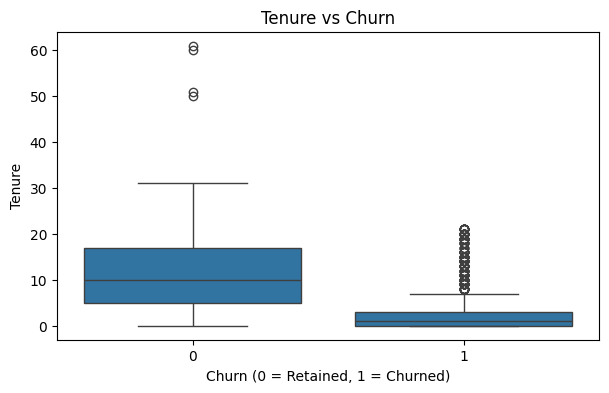

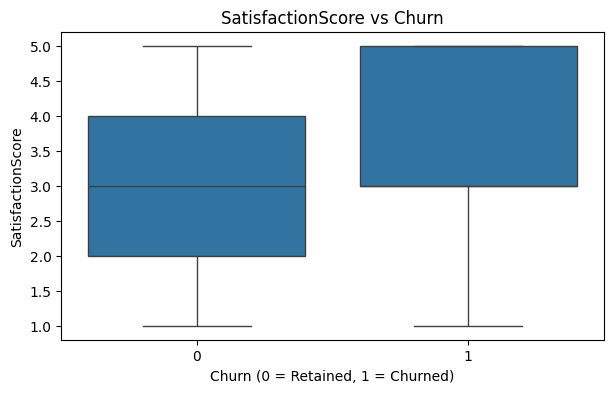

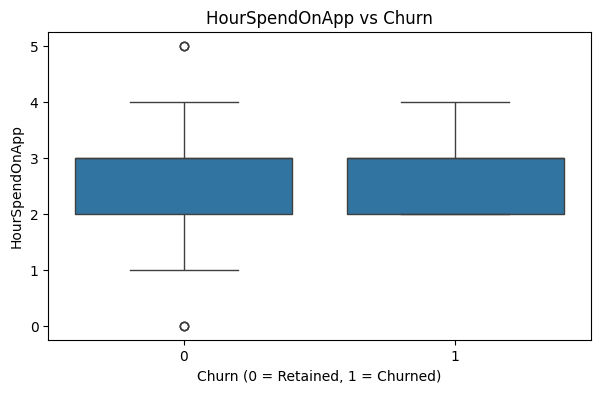

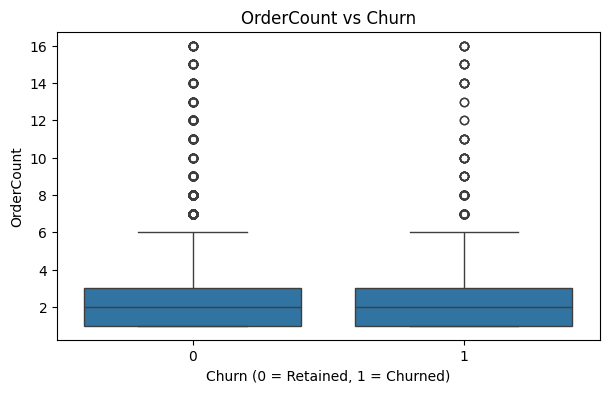

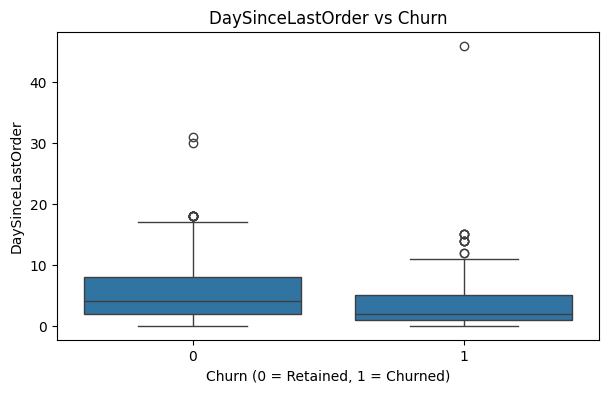

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = [
    "Tenure",
    "SatisfactionScore",
    "HourSpendOnApp",
    "OrderCount",
    "DaySinceLastOrder"
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=feature)
    plt.title(f"{feature} vs Churn")
    plt.xlabel("Churn (0 = Retained, 1 = Churned)")
    plt.ylabel(feature)
    plt.show()
    print()

* Tenure

Churned customers generally have much lower tenure than retained customers, making tenure a potentially important churn indicator.

* Satisfaction Score

Churned customers show a slightly higher satisfaction score, which is an unexpected pattern that needs further investigation.

* Hour Spend on App

Both groups have very similar app usage, so this feature does not show a strong visual difference.

* Order Count

The order count distributions are quite similar for both groups, with only a small difference in their averages.

* Day Since Last Order

The two groups show some difference in recent order activity, although the pattern is not very strong.

##  Categorical Features vs Churn

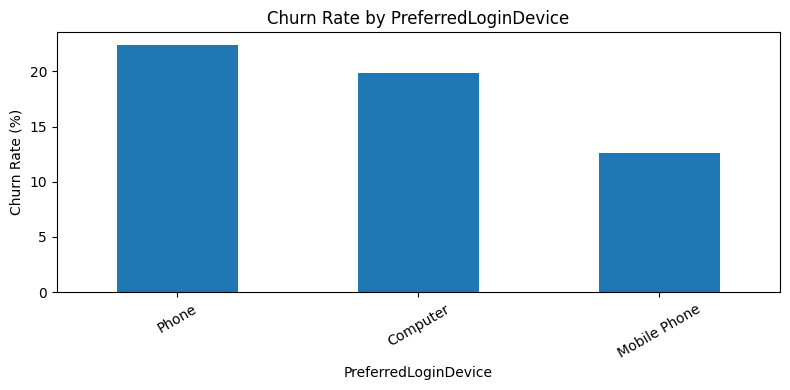

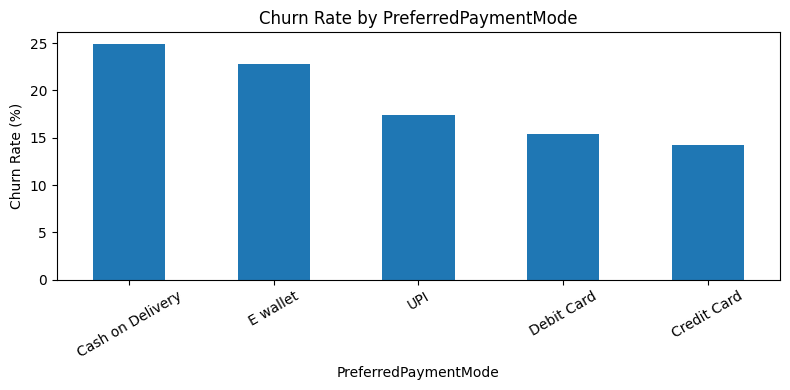

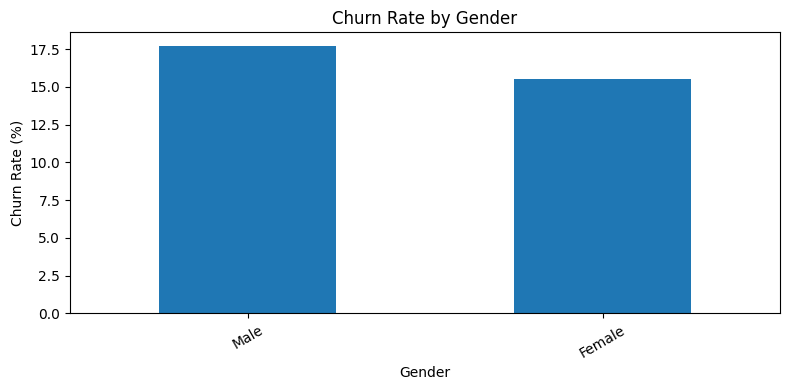

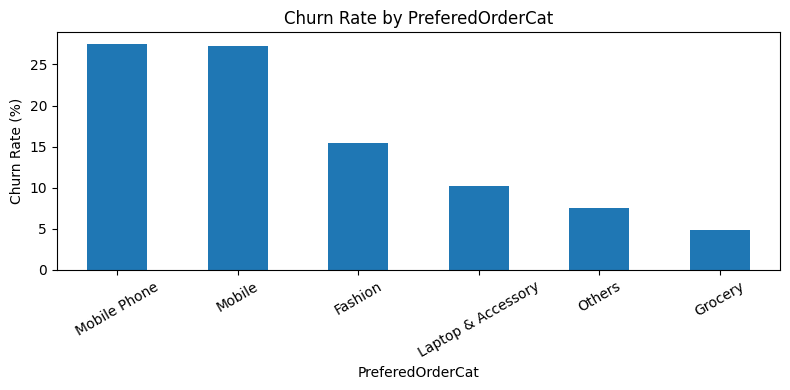

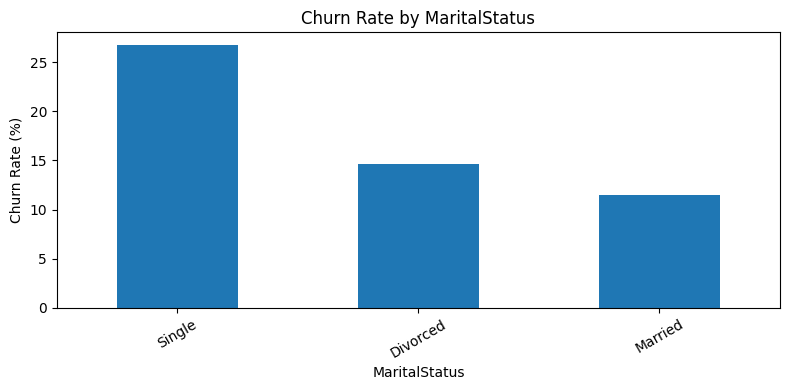

In [29]:
categorical_features = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

for feature in categorical_features:
    churn_rate = (
        df.groupby(feature)["Churn"]
        .mean()
        .sort_values(ascending=False) * 100
    )

    plt.figure(figsize=(8, 4))
    churn_rate.plot(kind="bar")
    plt.title(f"Churn Rate by {feature}")
    plt.ylabel("Churn Rate (%)")
    plt.xlabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

* Preferred Login Device

Churn rate is highest among customers using phones and lowest among mobile-phone users.

* Preferred Payment Mode

Customers using Cash on Delivery and E-wallets show higher churn rates than customers using cards.

* Gender

Male customers have a slightly higher churn rate than female customers.

* Preferred Order Category

Mobile Phone and Mobile customers have the highest churn rates, while Grocery customers have the lowest.

* Marital Status

Single customers show a noticeably higher churn rate than married and divorced customers.

Churn rates vary noticeably across several customer categories, particularly order category, payment mode, login device and marital status. These relationships will be further investigated using statistical testing.

# Hypothesis Testing

##  Tenure vs Churn
* H₀ (Null Hypothesis):
The average tenure is the same for churned and retained customers.

* H₁ (Alternative Hypothesis):
The average tenure is different between churned and retained customers.

In [30]:
from scipy.stats import ttest_ind

retained_tenure = df[df["Churn"] == 0]["Tenure"].dropna()
churned_tenure = df[df["Churn"] == 1]["Tenure"].dropna()

t_stat, p_value = ttest_ind(
    retained_tenure,
    churned_tenure,
    equal_var=False
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", p_value)

T-statistic: 36.157
P-value: 1.400133062144457e-214


In [31]:
if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in tenure between churned and retained customers.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that tenure differs between the two groups.")

Result: Reject the null hypothesis.
There is a statistically significant difference in tenure between churned and retained customers.


Low tenure is significantly associated with customer churn

##  Satisfaction Score vs Churn

* H₀:The average satisfaction score is the same for churned and retained customers.

* H₁:The average satisfaction score is different between churned and retained customers.

In [32]:
retained_satisfaction = df[df["Churn"] == 0]["SatisfactionScore"].dropna()
churned_satisfaction = df[df["Churn"] == 1]["SatisfactionScore"].dropna()

t_stat, p_value = ttest_ind(
    retained_satisfaction,
    churned_satisfaction,
    equal_var=False
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in satisfaction scores between churned and retained customers.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that satisfaction scores differ between the two groups.")

T-statistic: -8.101
P-value: 1.1847878426006565e-15
Result: Reject the null hypothesis.
There is a statistically significant difference in satisfaction scores between churned and retained customers.


## Preferred Order Category vs Churn

**H₀:** Preferred order category and churn are independent.

**H₁:** Preferred order category and churn are associated.

In [33]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["PreferedOrderCat"],
    df["Churn"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("Preferred order category is significantly associated with churn.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of an association between order category and churn.")

Chi-square statistic: 288.639
P-value: 2.7708325346337454e-60
Result: Reject the null hypothesis.
Preferred order category is significantly associated with churn.


## Preferred Payment Mode vs Churn

**H₀:** Preferred payment mode and churn are independent.

**H₁:** Preferred payment mode and churn are associated.

In [34]:
contingency_table = pd.crosstab(
    df["PreferredPaymentMode"],
    df["Churn"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("Preferred payment mode is significantly associated with churn.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of an association between payment mode and churn.")

Chi-square statistic: 51.829
P-value: 1.4978570960706217e-10
Result: Reject the null hypothesis.
Preferred payment mode is significantly associated with churn.


## Conclusion
The statistical tests confirm that tenure, satisfaction score, preferred order category and preferred payment mode have significant relationships with customer churn. These findings will guide the next stage of feature preparation and predictive modelling.

# Feature Engineering & Data Preparation

In [6]:
# copy
model_df = df.copy()

# Remove CustomerID
model_df = model_df.drop(columns=["CustomerID"])

print("Shape of modelling dataset:", model_df.shape)
model_df.head()

Shape of modelling dataset: (5630, 19)


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [7]:

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (5630, 18)
y shape: (5630,)

Target distribution:
Churn
0    4682
1     948
Name: count, dtype: int64


## Train-test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (4504, 18)
Testing features: (1126, 18)

Training target distribution:
Churn
0    3746
1     758
Name: count, dtype: int64

Testing target distribution:
Churn
0    936
1    190
Name: count, dtype: int64


In [9]:
# Identify numerical and categorical features

categorical_features = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Numerical features:
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Number of categorical features: 5
Number of numerical features: 13


## Preprocessing Pipeline


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pre_lr = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler())
    ]), numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

models = {
    "Logistic Regression": Pipeline([
        ("p", pre_lr),
        ("c", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ))
    ]),
    
    "Random Forest": Pipeline([
        ("p", preprocessor),
        ("c", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "XGBoost": Pipeline([
        ("p", preprocessor),
        ("c", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
            random_state=42,
            eval_metric="logloss"
        ))
    ])
}



In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=[
            "roc_auc",
            "average_precision",
            "recall",
            "precision",
            "f1"
        ]
    )
    
    rows.append({
        "Model": name,
        "ROC-AUC": f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
        "PR-AUC": f"{scores['test_average_precision'].mean():.3f} ± {scores['test_average_precision'].std():.3f}",
        "Recall": f"{scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}",
        "Precision": f"{scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}",
        "F1": f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}"
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df

,ROC-AUC,PR-AUC,Recall,Precision,F1
Model,,,,,
Logistic Regression,0.890 ± 0.004,0.700 ± 0.016,0.809 ± 0.022,0.457 ± 0.022,0.584 ± 0.020
Random Forest,0.981 ± 0.004,0.923 ± 0.017,0.844 ± 0.044,0.830 ± 0.028,0.837 ± 0.034
XGBoost,0.983 ± 0.002,0.930 ± 0.013,0.912 ± 0.033,0.819 ± 0.026,0.863 ± 0.021


Top 15 Important Features:


,Feature,Importance
0,num__Tenure,0.267813
1,num__CashbackAmount,0.083393
2,num__Complain,0.073892
3,num__DaySinceLastOrder,0.059836
4,num__WarehouseToHome,0.057673
5,num__NumberOfAddress,0.048899
6,num__SatisfactionScore,0.045633
7,num__OrderAmountHikeFromlastYear,0.045443
8,num__OrderCount,0.027274
9,cat__MaritalStatus_Single,0.027027


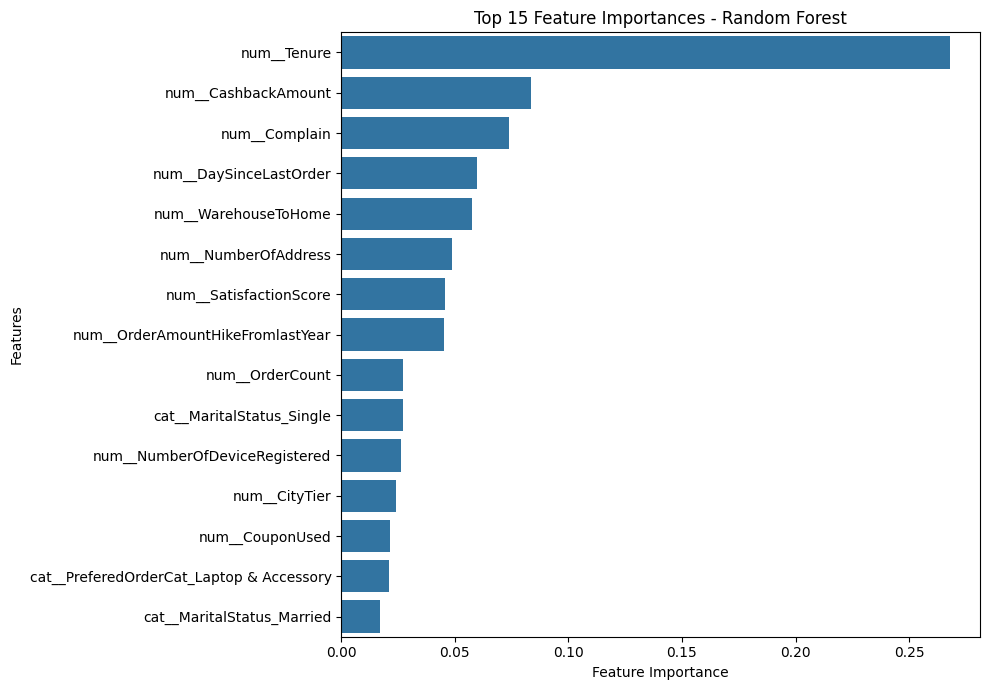

In [13]:
# FEATURE IMPORTANCE ANALYSIS - RANDOM FOREST

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = models["Random Forest"]

rf_model.fit(X, y)

rf_classifier = rf_model.named_steps["c"]

feature_names = (
    rf_model.named_steps["p"].get_feature_names_out()
)

importance_values = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 15 Important Features:")
display(feature_importance_df.head(15))


plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [42]:
key = lambda d: d.astype(str).agg("|".join, axis=1)
print("duplicate feature rows:", X.duplicated().sum())
print("test rows with exact twin in train:", key(X_test).isin(set(key(X_train))).mean())

duplicate feature rows: 556
test rows with exact twin in train: 0.1714031971580817


In [43]:
# checking model performance after removing duplicate rows
d = model_df.drop_duplicates()
Xd, yd = d.drop(columns="Churn"), d["Churn"]

rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        Xd,
        yd,
        cv=cv,
        scoring=["roc_auc", "recall", "precision", "f1"]
    )
    
    rows.append({
        "Model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Recall": scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1": scores["test_f1"].mean()
    })

dedup_df = pd.DataFrame(rows).set_index("Model").round(3)

print(f"Rows before deduplication: {len(model_df)}")
print(f"Rows after deduplication: {len(d)}")
dedup_df

Rows before deduplication: 5630
Rows after deduplication: 5074


,ROC-AUC,Recall,Precision,F1
Model,,,,
Logistic Regression,0.890,0.810,0.457,0.584
Random Forest,0.976,0.829,0.831,0.830
XGBoost,0.982,0.916,0.836,0.874


The important observation is that after removing duplicate feature rows, XGBoost still has:

ROC-AUC = 0.982

So the strong performance does not disappear after deduplication.

## Hyperparameter Optimization XGB

In [44]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform

xgb_pipe = models["XGBoost"]

param_dist = {
    "c__n_estimators": randint(200, 600),
    "c__max_depth": randint(3, 8),
    "c__learning_rate": uniform(0.02, 0.13),
    "c__subsample": uniform(0.6, 0.4),
    "c__colsample_bytree": uniform(0.6, 0.4),
    "c__min_child_weight": randint(1, 8),
    "c__reg_lambda": uniform(0.5, 4)
}

inner = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

outer = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="average_precision",
    cv=inner,
    random_state=42,
    n_jobs=-1
)

nested = cross_val_score(
    search,
    X,
    y,
    cv=outer,
    scoring="average_precision"
)

print(f"Nested PR-AUC: {nested.mean():.3f} ± {nested.std():.3f}")

search.fit(X, y)

best_params_df = pd.DataFrame(
    search.best_params_.items(),
    columns=["Parameter", "Best Value"]
)

best_params_df

Nested PR-AUC: 0.967 ± 0.011


,Parameter,Best Value
0,c__colsample_bytree,0.687506
1,c__learning_rate,0.092553
2,c__max_depth,6.000000
3,c__min_child_weight,1.000000
4,c__n_estimators,517.000000
5,c__reg_lambda,4.387128
6,c__subsample,0.984979


In [45]:
nested_d = cross_val_score(
    search,
    Xd,
    yd,
    cv=outer,
    scoring="average_precision"
)

print(f"Deduplicated Nested PR-AUC: {nested_d.mean():.3f} ± {nested_d.std():.3f}")

Deduplicated Nested PR-AUC: 0.958 ± 0.014


The nested PR-AUC was 0.967, and after removing duplicate feature rows it was 0.958, so the model's performance remained strong."

In [47]:
#threshold analysis
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, precision_score, recall_score

p = cross_val_predict(
    search,
    X,
    y,
    cv=outer,
    method="predict_proba"
)[:, 1]

roc_auc = roc_auc_score(y, p)

threshold_rows = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (p >= threshold).astype(int)
    
    threshold_rows.append({
        "Threshold": threshold,
        "Recall": recall_score(y, pred),
        "Precision": precision_score(y, pred)
    })

threshold_df = pd.DataFrame(threshold_rows)

print(f"ROC-AUC: {roc_auc:.4f}")

threshold_df.round(3)

ROC-AUC: 0.9907


,Threshold,Recall,Precision
0,0.3,0.934,0.913
1,0.4,0.931,0.930
2,0.5,0.930,0.946
3,0.6,0.926,0.952
4,0.7,0.919,0.959


The final XGBoost pipeline combines preprocessing and the tuned classifier into a single pipeline. The model demonstrates strong discrimination between churn and non-churn customers and provides probability-based predictions that can be adjusted using different classification thresholds for customer-retention use cases.

In [48]:
import joblib, sklearn, xgboost, numpy, pandas, scipy

final_model = search.best_estimator_
joblib.dump(final_model, "churn_xgboost_pipeline.pkl")

print("sklearn", sklearn.__version__)
print("xgboost", xgboost.__version__)
print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("scipy", scipy.__version__)

# sanity check: the reloaded model gives identical outputs
m = joblib.load("churn_xgboost_pipeline.pkl")
print((m.predict_proba(X.head(20)) == final_model.predict_proba(X.head(20))).all())

sklearn 1.7.2
xgboost 3.2.0
numpy 1.24.3
pandas 2.0.3
scipy 1.15.3
True


In [ ]:
import joblib



# If 'model' is a Pipeline, extract the final classifier step
classifier = m.named_steps["classifier"]  
# Inspect feature importances
importances = classifier.feature_importances_
for name, importance in zip(FEATURE_ORDER, importances):
    print(f"{name}: {importance:.4f}")